# GVH — Quantum Potential Well Validation 0.1

## Validation méthodologique du pipeline du puits de potentiel infini

Ce notebook évalue la robustesse des observables produites par :

`GVH_Quantum_Potential_Well_Pipeline_0.1.ipynb`

Il ne modifie pas le pipeline de référence et ne recalcule pas les solutions
quantiques principales.

Les analyses portent sur :

1. la comparaison des modèles de survie ;
2. l'analyse de l'atténuation effective \(B_{\mathrm{eff}}(u)\) ;
3. la sensibilité à la résolution spatiale ;
4. la sensibilité au nombre d'états ;
5. la synthèse de robustesse.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [4]:
import pandas as pd

SURVIVAL_URL = (
    "https://raw.githubusercontent.com/"
    "col38470682/"
    "Univers/"
    "main/"
    "gvh_dynamic/"
    "Data/"
    "archive/"
    "potential_well/"
    "GVH_Quantum_Potential_Well_Survival_0.1.csv"
)

survival_reference_df = pd.read_csv(SURVIVAL_URL)

print(survival_reference_df.shape)
display(survival_reference_df.head())

(200, 4)


,u_threshold,R_empirical,R_exponential,residual
0,0.000000,1.000,1.250962,-0.250962
1,0.005025,1.000,1.243969,-0.243969
2,0.010050,0.999,1.237015,-0.238015
3,0.015075,0.999,1.230099,-0.231099
4,0.020101,0.999,1.223222,-0.224222


In [5]:
# ============================================================
# 1.2 — Vérification de l’intégrité des données
# ============================================================

required_columns = [
    "u_threshold",
    "R_empirical",
    "R_exponential",
    "residual"
]

missing_columns = [
    column
    for column in required_columns
    if column not in survival_reference_df.columns
]

if missing_columns:
    raise ValueError(
        f"Colonnes manquantes : {missing_columns}"
    )

u_reference = survival_reference_df[
    "u_threshold"
].to_numpy(dtype=float)

R_reference = survival_reference_df[
    "R_empirical"
].to_numpy(dtype=float)

nan_count = survival_reference_df[
    required_columns
].isna().sum().sum()

print("Nombre de points :", len(u_reference))
print("Valeurs manquantes :", nan_count)
print("u_min :", u_reference.min())
print("u_max :", u_reference.max())
print("R_min :", R_reference.min())
print("R_max :", R_reference.max())
print(
    "Décroissance monotone :",
    np.all(np.diff(R_reference) <= 1e-12)
)

Nombre de points : 200
Valeurs manquantes : 0
u_min : 0.0
u_max : 1.0
R_min : 0.0
R_max : 1.0
Décroissance monotone : True


In [6]:
# ============================================================
# 1.3 — Préparation des données d'ajustement
# ============================================================

fit_mask = (
    np.isfinite(u_reference)
    & np.isfinite(R_reference)
    & (R_reference > 0.0)
)

u_fit = u_reference[fit_mask]
R_fit = R_reference[fit_mask]

print("Points totaux :", len(u_reference))
print("Points utilisés pour les ajustements :", len(u_fit))
print("Points exclus :", len(u_reference) - len(u_fit))

Points totaux : 200
Points utilisés pour les ajustements : 199
Points exclus : 1


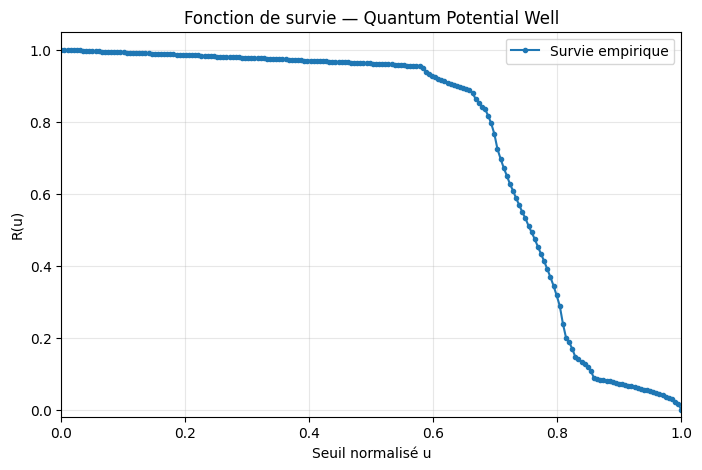

In [7]:
# ============================================================
# 1.4 — Courbe empirique de référence
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    u_reference,
    R_reference,
    'o-',
    markersize=3,
    linewidth=1.5,
    label="Survie empirique"
)

plt.xlabel("Seuil normalisé u")
plt.ylabel("R(u)")
plt.title("Fonction de survie — Quantum Potential Well")

plt.grid(alpha=0.3)
plt.legend()

plt.xlim(0,1)
plt.ylim(-0.02,1.05)

plt.show()

In [8]:
# ============================================================
# 1.5 — Ajustement exponentiel libre
# ============================================================

from scipy.optimize import curve_fit

# Modèle exponentiel
def exponential_model(u, A, B):
    return A * np.exp(-B * u)

# Ajustement
popt_exp, _ = curve_fit(
    exponential_model,
    u_fit,
    R_fit,
    p0=[1.0, 1.0],
    maxfev=10000
)

A_exp, B_exp = popt_exp

# Prédiction
R_exp_fit = exponential_model(u_fit, A_exp, B_exp)

# Indicateurs
residuals = R_fit - R_exp_fit

ss_res = np.sum(residuals**2)
ss_tot = np.sum((R_fit - np.mean(R_fit))**2)

R2_exp = 1 - ss_res / ss_tot
RMSE_exp = np.sqrt(np.mean(residuals**2))

print(f"A = {A_exp:.6f}")
print(f"B = {B_exp:.6f}")
print(f"R² = {R2_exp:.6f}")
print(f"RMSE = {RMSE_exp:.6f}")

A = 1.250960
B = 1.115620
R² = 0.571769
RMSE = 0.232148


In [9]:
# ============================================================
# 1.6 — Ajustement exponentiel contraint : A = 1
# ============================================================

def exponential_constrained_model(u, B):
    return np.exp(-B * u)

popt_exp_c, _ = curve_fit(
    exponential_constrained_model,
    u_fit,
    R_fit,
    p0=[1.0],
    bounds=(0.0, np.inf),
    maxfev=10000
)

B_exp_c = popt_exp_c[0]

R_exp_c_fit = exponential_constrained_model(
    u_fit,
    B_exp_c
)

residuals_exp_c = R_fit - R_exp_c_fit

ss_res_exp_c = np.sum(residuals_exp_c**2)
ss_tot_exp_c = np.sum(
    (R_fit - np.mean(R_fit))**2
)

R2_exp_c = 1 - ss_res_exp_c / ss_tot_exp_c
RMSE_exp_c = np.sqrt(
    np.mean(residuals_exp_c**2)
)

print("A = 1.000000 (contraint)")
print(f"B = {B_exp_c:.6f}")
print(f"R² = {R2_exp_c:.6f}")
print(f"RMSE = {RMSE_exp_c:.6f}")

A = 1.000000 (contraint)
B = 0.753859
R² = 0.476603
RMSE = 0.256650


In [10]:
# ============================================================
# 1.7 — Ajustement Weibull
# ============================================================

def weibull_model(u, lam, k):
    return np.exp(-((u / lam) ** k))

popt_weibull, _ = curve_fit(
    weibull_model,
    u_fit,
    R_fit,
    p0=[0.8, 5.0],
    bounds=(
        [1e-8, 1e-8],
        [np.inf, np.inf]
    ),
    maxfev=20000
)

lambda_weibull, k_weibull = popt_weibull

R_weibull_fit = weibull_model(
    u_fit,
    lambda_weibull,
    k_weibull
)

residuals_weibull = R_fit - R_weibull_fit

ss_res_weibull = np.sum(residuals_weibull**2)
ss_tot_weibull = np.sum(
    (R_fit - np.mean(R_fit))**2
)

R2_weibull = 1 - ss_res_weibull / ss_tot_weibull
RMSE_weibull = np.sqrt(
    np.mean(residuals_weibull**2)
)

print(f"lambda = {lambda_weibull:.6f}")
print(f"k = {k_weibull:.6f}")
print(f"R² = {R2_weibull:.6f}")
print(f"RMSE = {RMSE_weibull:.6f}")

lambda = 0.786936
k = 10.062669
R² = 0.994892
RMSE = 0.025355


In [11]:
# ============================================================
# 1.8 — Ajustement logistique
# ============================================================

def logistic_model(u, u0, k):
    return 1.0 / (1.0 + np.exp((u - u0) / k))

# Ajustement
popt_log, _ = curve_fit(
    logistic_model,
    u_fit,
    R_fit,
    p0=[0.75, 0.05],
    bounds=(
        [0.0, 1e-6],
        [1.0, np.inf]
    ),
    maxfev=20000
)

u0_log, k_log = popt_log

R_log_fit = logistic_model(
    u_fit,
    u0_log,
    k_log
)

# Statistiques
residuals_log = R_fit - R_log_fit

ss_res_log = np.sum(residuals_log**2)
ss_tot_log = np.sum((R_fit - np.mean(R_fit))**2)

R2_log = 1 - ss_res_log / ss_tot_log
RMSE_log = np.sqrt(np.mean(residuals_log**2))

print(f"u0 = {u0_log:.6f}")
print(f"k = {k_log:.6f}")
print(f"R² = {R2_log:.6f}")
print(f"RMSE = {RMSE_log:.6f}")

u0 = 0.754686
k = 0.052123
R² = 0.996227
RMSE = 0.021791


In [12]:
# ============================================================
# 1.9 — Comparaison des modèles
# ============================================================

def information_criteria(y_true, y_pred, n_params):
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)

    aic = n * np.log(rss / n) + 2 * n_params
    bic = n * np.log(rss / n) + n_params * np.log(n)

    return aic, bic

AIC_exp, BIC_exp = information_criteria(
    R_fit,
    R_exp_fit,
    2
)

AIC_exp_c, BIC_exp_c = information_criteria(
    R_fit,
    R_exp_c_fit,
    1
)

AIC_weibull, BIC_weibull = information_criteria(
    R_fit,
    R_weibull_fit,
    2
)

AIC_log, BIC_log = information_criteria(
    R_fit,
    R_log_fit,
    2
)

comparison_models = pd.DataFrame({

    "Model": [
        "Exponential",
        "Exponential (A=1)",
        "Weibull",
        "Logistic"
    ],

    "R²": [
        R2_exp,
        R2_exp_c,
        R2_weibull,
        R2_log
    ],

    "RMSE": [
        RMSE_exp,
        RMSE_exp_c,
        RMSE_weibull,
        RMSE_log
    ],

    "AIC": [
        AIC_exp,
        AIC_exp_c,
        AIC_weibull,
        AIC_log
    ],

    "BIC": [
        BIC_exp,
        BIC_exp_c,
        BIC_weibull,
        BIC_log
    ]

})

comparison_models = comparison_models.sort_values(
    by="AIC"
)

display(comparison_models.round(6))

,Model,R²,RMSE,AIC,BIC
3,Logistic,0.996227,0.021791,-1518.853046,-1512.266437
2,Weibull,0.994892,0.025355,-1458.562989,-1451.976380
0,Exponential,0.571769,0.232148,-577.231705,-570.645095
1,Exponential (A=1),0.476603,0.256650,-539.296617,-536.003312


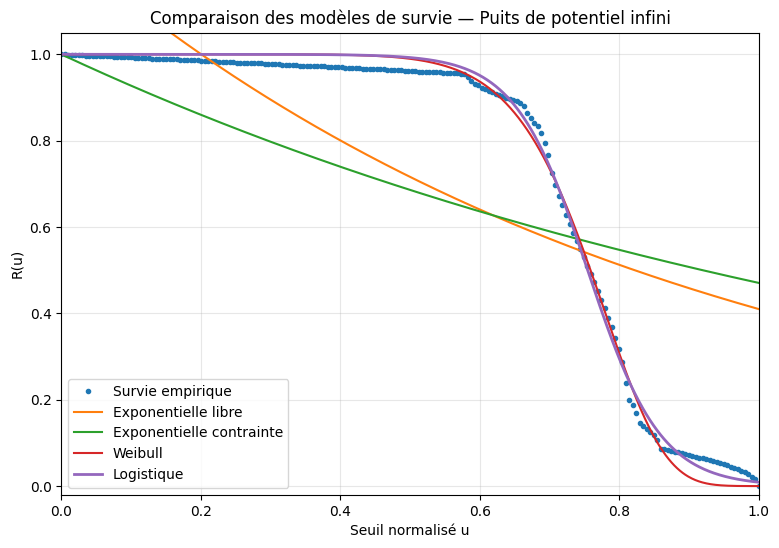

In [13]:
# ============================================================
# 1.10 — Comparaison graphique des modèles de survie
# ============================================================

u_plot = np.linspace(0.0, 1.0, 1000)

plt.figure(figsize=(9, 6))

plt.plot(
    u_reference,
    R_reference,
    "o",
    markersize=3,
    label="Survie empirique"
)

plt.plot(
    u_plot,
    exponential_model(u_plot, A_exp, B_exp),
    linewidth=1.5,
    label="Exponentielle libre"
)

plt.plot(
    u_plot,
    exponential_constrained_model(u_plot, B_exp_c),
    linewidth=1.5,
    label="Exponentielle contrainte"
)

plt.plot(
    u_plot,
    weibull_model(u_plot, lambda_weibull, k_weibull),
    linewidth=1.5,
    label="Weibull"
)

plt.plot(
    u_plot,
    logistic_model(u_plot, u0_log, k_log),
    linewidth=2.0,
    label="Logistique"
)

plt.xlabel("Seuil normalisé u")
plt.ylabel("R(u)")
plt.title("Comparaison des modèles de survie — Puits de potentiel infini")

plt.xlim(0.0, 1.0)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Conclusion — Validation de la fonction de survie

Quatre modèles ont été comparés sur la fonction de survie empirique du
puits de potentiel infini :

- exponentielle libre ;
- exponentielle contrainte par \(R(0)=1\) ;
- Weibull ;
- logistique décroissante.

Le modèle logistique fournit la meilleure description globale :

\[
R^2 = 0.996227,
\qquad
\mathrm{RMSE} = 0.021791,
\]

avec les valeurs d'AIC et de BIC les plus faibles.

La Weibull fournit également un très bon ajustement, mais reste moins
performante que la logistique.

Les modèles exponentiels décrivent mal la combinaison observée d'un
plateau initial et d'une transition rapide.

Ainsi, les paramètres exponentiels \(A_H\) et \(B_H\) sont conservés
comme observables comparatives standardisées du pipeline GVH, mais ils
ne constituent pas la meilleure représentation statistique de la
fonction de survie de ce benchmark.

Pour le puits de potentiel infini, la fonction de survie est mieux
interprétée comme une transition sigmoïde centrée autour de :

\[
u_0 \approx 0.754686.
\]

In [14]:
# ============================================================
# Export — Comparaison des modèles
# ============================================================

comparison_models.to_csv(
    "GVH_Quantum_Potential_Well_Model_Comparison_0.1.csv",
    index=False
)

print("Export terminé : GVH_Quantum_Potential_Well_Model_Comparison_0.1.csv")

Export terminé : GVH_Quantum_Potential_Well_Model_Comparison_0.1.csv


In [15]:
# ============================================================
# Export — Courbes ajustées
# ============================================================

validation_curves = pd.DataFrame({

    "u": u_reference,
    "R_empirical": R_reference,

    "R_exponential":
        exponential_model(u_reference, A_exp, B_exp),

    "R_exponential_constrained":
        exponential_constrained_model(u_reference, B_exp_c),

    "R_weibull":
        weibull_model(u_reference, lambda_weibull, k_weibull),

    "R_logistic":
        logistic_model(u_reference, u0_log, k_log)

})

validation_curves.to_csv(
    "GVH_Quantum_Potential_Well_Model_Fits_0.1.csv",
    index=False
)

print("Export terminé : GVH_Quantum_Potential_Well_Model_Fits_0.1.csv")

Export terminé : GVH_Quantum_Potential_Well_Model_Fits_0.1.csv


In [16]:
# ============================================================
# Export — Paramètres des modèles
# ============================================================

model_parameters = pd.DataFrame({

    "Model": [
        "Exponential",
        "Exponential_A1",
        "Weibull",
        "Logistic"
    ],

    "Parameter_1": [
        A_exp,
        1.0,
        lambda_weibull,
        u0_log
    ],

    "Parameter_2": [
        B_exp,
        B_exp_c,
        k_weibull,
        k_log
    ]

})

model_parameters.to_csv(
    "GVH_Quantum_Potential_Well_Model_Parameters_0.1.csv",
    index=False
)

print("Export terminé : GVH_Quantum_Potential_Well_Model_Parameters_0.1.csv")

Export terminé : GVH_Quantum_Potential_Well_Model_Parameters_0.1.csv
